In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# =====================
# 1) Chargement
# =====================
# Chargement
df = pd.read_csv("../../data/processed/02_dataset_silver.csv")

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values("date")

TARGET = "taux_chomage_total_insee"

X = df.drop(columns=[TARGET], errors="ignore")
y = df[TARGET]

# garder uniquement variables numériques
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)

# =====================
# 2) Mutual Information
# =====================
X_imp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=X.columns
)

mi = mutual_info_regression(X_imp, y.fillna(y.median()), random_state=42)
mi_rank = pd.Series(mi, index=X.columns)\
            .sort_values(ascending=False)

print("\n===== TOP 15 - Mutual Information =====")
print(mi_rank.head(15))

# =====================
# 3) Lasso (Time-aware)
# =====================
tscv = TimeSeriesSplit(n_splits=5)

lasso_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=tscv, random_state=42, max_iter=50000))
])

lasso_pipe.fit(X, y.fillna(y.median()))

coef = lasso_pipe.named_steps["lasso"].coef_

lasso_rank = pd.Series(
    np.abs(coef),
    index=X.columns
).sort_values(ascending=False)

print("\n===== TOP 15 - Lasso =====")
print(lasso_rank[lasso_rank > 1e-6].head(15))


===== TOP 15 - Mutual Information =====
taux_chomage_ocde               2.107548
taux_chomage_25_49_insee        1.662684
taux_chomage_homme_insee        1.327153
taux_chomage_femme_insee        1.104566
ict                             1.079808
population_active               0.967916
demandeur_total_abcd_moins25    0.875748
taux_chomage_15_24_insee        0.861599
pib                             0.857453
demandeur_homme_abcd_moins25    0.848664
demandeur_total_abcd_total      0.830648
demandeur_femme_abcd_plus50     0.830290
demandeur_homme_abcd_2549       0.809865
demandeur_total_abcd_2549       0.801405
demandeur_total_abcd_plus50     0.781351
dtype: float64

===== TOP 15 - Lasso =====
taux_chomage_homme_insee         0.519724
taux_chomage_femme_insee         0.424016
taux_chomage_25_49_insee         0.071215
taux_chomage_15_24_insee         0.053094
pib_logdiff                      0.006701
taux_chomage_50_plus_insee       0.004321
pop_active_var                   0.001155
taux_ch

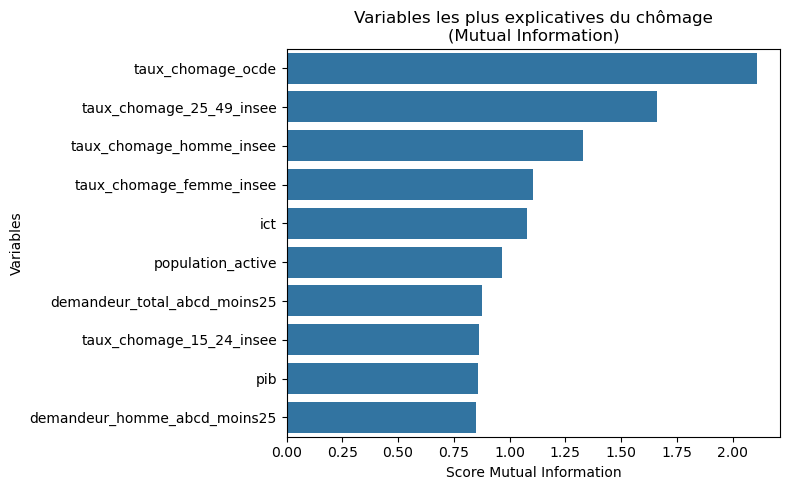

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# prendre les 10 variables les plus importantes
top_mi = mi_rank.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_mi.values, y=top_mi.index)

plt.title("Variables les plus explicatives du chômage\n(Mutual Information)")
plt.xlabel("Score Mutual Information")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

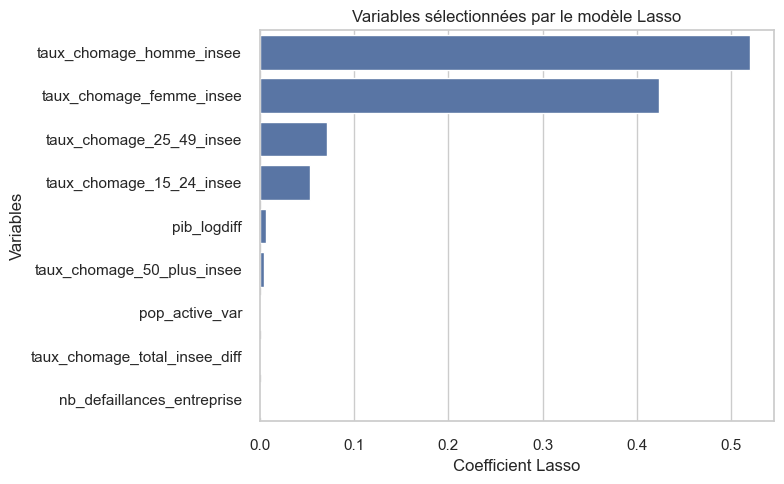

In [10]:
top_lasso = lasso_rank[lasso_rank > 0].head(10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,5))
sns.barplot(x=top_lasso.values, y=top_lasso.index)

plt.title("Variables sélectionnées par le modèle Lasso")
plt.xlabel("Coefficient Lasso")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_19212\3895150151.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


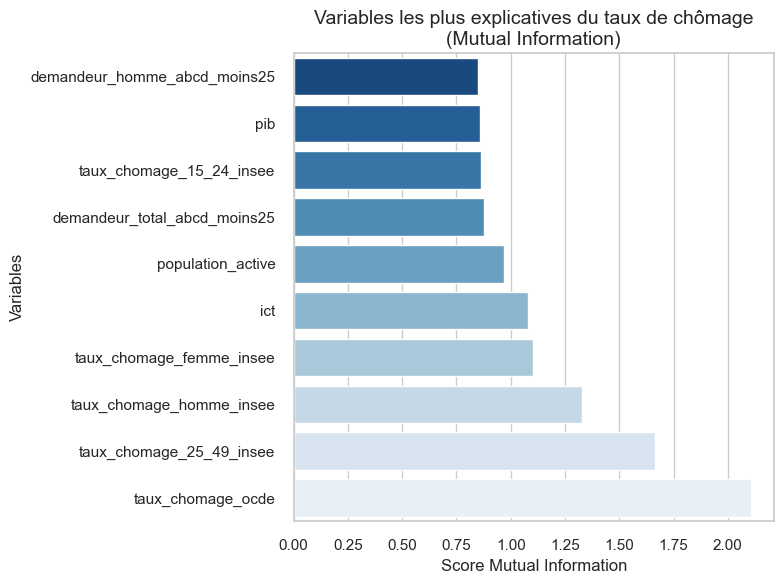

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Top variables
top_mi = mi_rank.head(10).sort_values()

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_mi.values,
    y=top_mi.index,
    palette="Blues_r"
)

plt.title(
    "Variables les plus explicatives du taux de chômage\n(Mutual Information)",
    fontsize=14
)

plt.xlabel("Score Mutual Information")
plt.ylabel("Variables")

plt.tight_layout()

plt.savefig("mutual_information_plot.png", dpi=300)

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_19212\502129081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


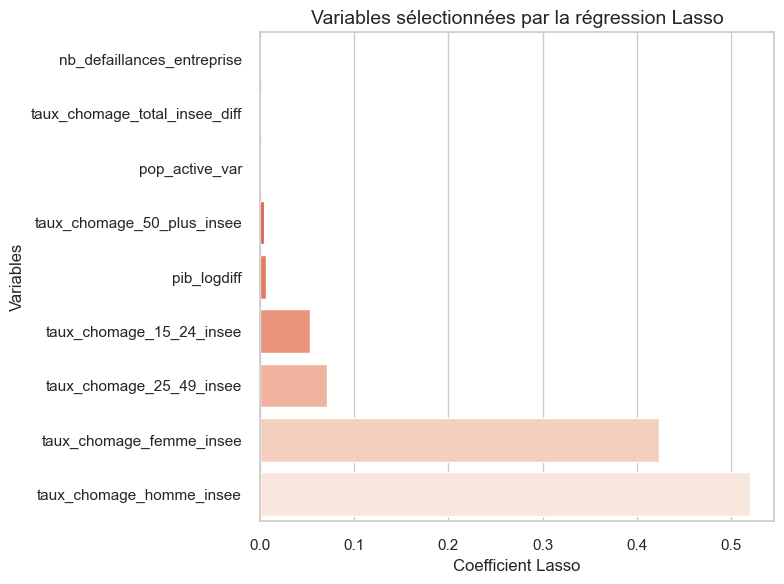

In [12]:
top_lasso = lasso_rank[lasso_rank > 0].head(10).sort_values()

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_lasso.values,
    y=top_lasso.index,
    palette="Reds_r"
)

plt.title(
    "Variables sélectionnées par la régression Lasso",
    fontsize=14
)

plt.xlabel("Coefficient Lasso")
plt.ylabel("Variables")

plt.tight_layout()

plt.savefig("lasso_plot.png", dpi=300)

plt.show()

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

TOP_N = 10
top = combined.sort_values("Score_combine", ascending=False).head(TOP_N).copy()
top = top.sort_values("Score_combine")  # pour affichage

melted = top.reset_index().melt(
    id_vars="index",
    value_vars=["MI_norm", "Lasso_norm"],
    var_name="Methode",
    value_name="Score"
).rename(columns={"index": "Variable"})

plt.figure(figsize=(10, 6))
sns.barplot(data=melted, x="Score", y="Variable", hue="Methode")

plt.title("Comparaison des scores par méthode (MI vs Lasso)", fontsize=14)
plt.xlabel("Score normalisé")
plt.ylabel("Variables")

plt.legend(title="Méthode")
plt.tight_layout()
plt.savefig("MI_vs_Lasso_comparaison.png", dpi=300)
plt.show()

NameError: name 'combined' is not defined

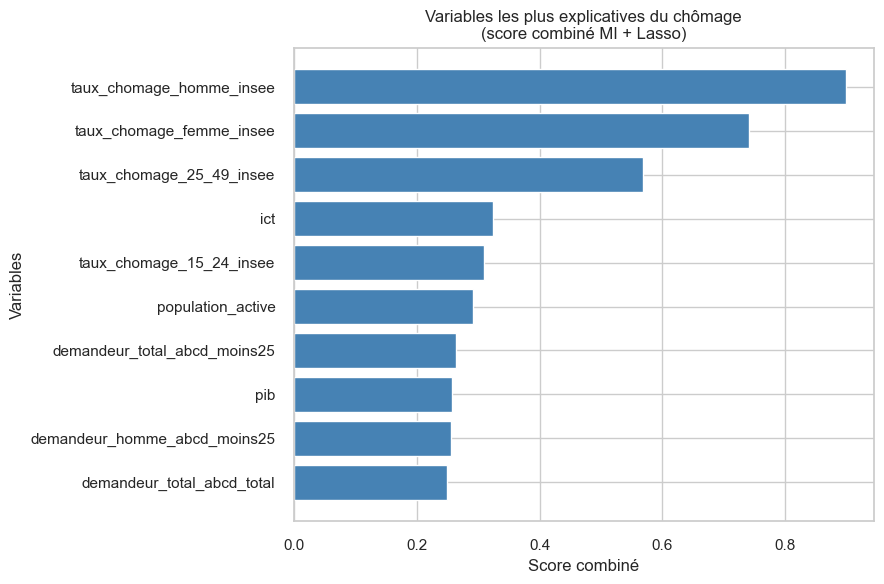

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# enlever taux_chomage_ocde
mi_rank_clean = mi_rank.drop("taux_chomage_ocde", errors="ignore")
lasso_rank_clean = lasso_rank.drop("taux_chomage_ocde", errors="ignore")

# normalisation
mi_norm = (mi_rank_clean - mi_rank_clean.min()) / (mi_rank_clean.max() - mi_rank_clean.min())
lasso_norm = (lasso_rank_clean - lasso_rank_clean.min()) / (lasso_rank_clean.max() - lasso_rank_clean.min())

# variables communes
common_vars = mi_norm.index.intersection(lasso_norm.index)

combined = pd.DataFrame({
    "MI_norm": mi_norm.loc[common_vars],
    "Lasso_norm": lasso_norm.loc[common_vars]
})

# score combiné
combined["Score_combine"] = combined.mean(axis=1)

# top variables
TOP_N = 10
top_combined = combined.sort_values("Score_combine", ascending=False).head(TOP_N)

# tri pour affichage
top_plot = top_combined.sort_values("Score_combine")

# graphique
plt.figure(figsize=(9,6))
plt.barh(top_plot.index, top_plot["Score_combine"], color="steelblue")

plt.title("Variables les plus explicatives du chômage\n(score combiné MI + Lasso)")
plt.xlabel("Score combiné")
plt.ylabel("Variables")

plt.tight_layout()
plt.savefig("variables_explicatives_chomage.png", dpi=300)

plt.show()